
# Deterministic MPC With PV, Grid Price, And BESS

This notebook adds a minimal electrical energy layer on top of the existing deterministic building MPC setup:

- `pv_kw` is treated as an exogenous electrical input time series.
- `grid_price_ct_per_kwh` is treated as an exogenous cost time series.
- the battery is a one-state model with energy state `E_bess_kwh`.
- no thermal storage is added.
- no uncertainty is used in this first step.

Energy routing is intentionally minimal:

- PV can supply the heat pump directly.
- PV can charge the battery.
- the battery can discharge to the heat pump.
- the grid can supply the heat pump.
- the battery is not charged from the grid.
- no export is modeled.

The notebook is self-contained and does not modify the existing MPC implementation.


In [1]:

from pathlib import Path
import sys
import warnings

import casadi as cas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

I4B_ROOT = Path("..").resolve()
if str(I4B_ROOT) not in sys.path:
    sys.path.insert(0, str(I4B_ROOT))

import src.disturbances as disturbances
import src.models.model_buildings as model_buildings
import src.models.model_hvac as model_hvac
from data.buildings import i4c


In [2]:

method = "2R2C"
h = 3600
nk = 24
offset_steps = 24 * 180

mdot_hp = 0.25
T_room_set_lower = 20.0

pv_peak_kw = 6.0
pv_performance_ratio = 0.9
grid_price_column = "EEX2015"

bess_capacity_kwh = 8.0
bess_power_max_kw = 4.0
bess_initial_energy_kwh = 0.0

soft_lower_constraint = False
slack_weight = 1e4

solve_baseline_case = True
baseline_pv_peak_kw = 0.0
baseline_bess_capacity_kwh = 0.0

u_min = 20.0
u_max = 65.0



## Exogenous Inputs

`data/grid/` currently contains:

- `grid_signals.csv`: hourly price-like signals with columns such as `EEX2015`, `EEX2018`, `EEX2020`
- `grid_signals_15min.csv`: residual-load signals, but no price column

For this first notebook, the grid cost signal is loaded from `grid_signals.csv` and resampled to the MPC timestep.

The PV input is handled as an exogenous time series `pv_kw`. In this initial version it is synthesized from the weather `ghi` series, so the optimization already sees PV as an external electrical input without changing the existing disturbance code.


In [3]:

def load_grid_price_series(index: pd.DatetimeIndex, repo_root: Path, column: str = "EEX2015") -> pd.Series:
    grid_hourly = pd.read_csv(repo_root / "data" / "grid" / "grid_signals.csv")
    if column not in grid_hourly.columns:
        raise KeyError(f"Grid column '{column}' not found in data/grid/grid_signals.csv")

    # Existing code scales EEX data from EUR/MWh to ct/kWh.
    values_ct_per_kwh = grid_hourly[column].to_numpy(dtype=float) * 0.001 * 100.0
    hourly_index = pd.date_range("2015-01-01 00:00:00", periods=len(values_ct_per_kwh), freq="h")
    return pd.Series(values_ct_per_kwh, index=hourly_index, name="grid_price_ct_per_kwh").reindex(index, method="ffill")


def build_pv_power_series(
    building_model,
    index: pd.DatetimeIndex,
    repo_root: Path,
    pv_peak_kw: float = 0.0,
    performance_ratio: float = 0.9,
) -> pd.Series:
    weather = disturbances.load_weather(
        latitude=building_model.params["position"]["lat"],
        longitude=building_model.params["position"]["long"],
        altitude=building_model.params["position"]["altitude"],
        year=index[0].year,
        repo_filepath=str(repo_root),
    )
    weather = weather.reindex(index, method="nearest")
    pv_kw = pv_peak_kw * performance_ratio * weather["ghi"].clip(lower=0.0) / 1000.0
    return pv_kw.rename("pv_kw")


def prepare_exogenous_data(
    building_model,
    repo_root: Path,
    h: int,
    nk: int,
    offset_steps: int = 0,
    pv_peak_kw: float = 0.0,
    performance_ratio: float = 0.9,
    grid_price_column: str = "EEX2015",
) -> pd.DataFrame:
    exo = disturbances.generate_disturbances_all(
        building_model=building_model,
        timestep=h,
        GRID_ON=False,
        repo_filepath=str(repo_root),
    ).iloc[offset_steps : offset_steps + nk + 1].copy()

    exo["grid_price_ct_per_kwh"] = load_grid_price_series(exo.index, repo_root, column=grid_price_column).to_numpy()
    exo["pv_kw"] = build_pv_power_series(
        building_model,
        exo.index,
        repo_root,
        pv_peak_kw=pv_peak_kw,
        performance_ratio=performance_ratio,
    ).to_numpy()
    return exo


building_model = model_buildings.Building(
    params=i4c,
    mdot_hp=mdot_hp,
    method=method,
    T_room_set_lower=T_room_set_lower,
)
hp_model = model_hvac.Heatpump_AW(mdot_HP=mdot_hp)

exo_main = prepare_exogenous_data(
    building_model,
    I4B_ROOT,
    h=h,
    nk=nk,
    offset_steps=offset_steps,
    pv_peak_kw=pv_peak_kw,
    performance_ratio=pv_performance_ratio,
    grid_price_column=grid_price_column,
)

exo_main[["T_amb", "Qdot_gains", "T_room_set_lower", "pv_kw", "grid_price_ct_per_kwh"]].head()


,T_amb,Qdot_gains,T_room_set_lower,pv_kw,grid_price_ct_per_kwh
2015-06-30 00:00:00,19.8,1573.28,20.0,0.0,2.944
2015-06-30 01:00:00,19.8,1573.28,20.0,0.0,2.936
2015-06-30 02:00:00,19.4,1573.28,20.0,0.0,2.949
2015-06-30 03:00:00,19.5,1573.28,20.0,0.0,2.752
2015-06-30 04:00:00,19.2,1573.28,20.0,0.0,2.758



## Deterministic Optimization Model

The optimization is deliberately kept minimal:

- building dynamics use the existing deterministic building model
- the heat pump supply temperature `T_hp_sup` remains the main thermal control input
- the battery adds exactly one dynamic state: `E_bess_kwh`
- all electrical routing variables are nonnegative power flows

Stage objective:

```text
stage_cost = dt_h * grid_price_ct_per_kwh * P_grid_to_hp_kw + slack_weight * s^2
```

Battery dynamics:

```text
E_{k+1} = E_k + dt_h * (P_pv_to_bess_kw - P_bess_to_hp_kw)
```

The battery starts empty by default, so the optimizer cannot use free initial stored energy.


In [4]:

def build_rk4_step_function(building_model, h: int) -> cas.Function:
    nx = len(building_model.state_keys)
    x = cas.SX.sym("x", nx)
    u = cas.SX.sym("u")
    p = cas.SX.sym("p", 2)
    rhs = building_model.calc_casadi(x, u, p)
    f = cas.Function("building_rhs", [x, u, p], [rhs])

    dt = float(h)
    k1 = f(x, u, p)
    k2 = f(x + 0.5 * dt * k1, u, p)
    k3 = f(x + 0.5 * dt * k2, u, p)
    k4 = f(x + dt * k3, u, p)
    x_next = x + dt / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)
    return cas.Function("building_step_rk4", [x, u, p], [x_next])


def solve_deterministic_pv_bess_case(
    *,
    building_model,
    hp_model,
    exo: pd.DataFrame,
    h: int,
    nk: int,
    x0: np.ndarray,
    bess_capacity_kwh: float,
    bess_power_max_kw: float,
    bess_initial_energy_kwh: float,
    u_min: float,
    u_max: float,
    soft_lower_constraint: bool,
    slack_weight: float,
    scenario_label: str,
):
    nx = len(building_model.state_keys)
    room_idx = building_model.state_keys.index("T_room")
    ret_idx = building_model.state_keys.index("T_hp_ret")
    dt_h = h / 3600.0
    step_fun = build_rk4_step_function(building_model, h)
    x_min, x_max, x_init = building_model.state_bounds()
    active_bess_power_max = bess_power_max_kw if bess_capacity_kwh > 0 else 0.0

    variables = []
    lbw = []
    ubw = []
    w0 = []
    constraints = []
    lbg = []
    ubg = []
    offset = 0
    slices = {key: [] for key in ["X", "E", "T_hp", "P_pv_hp", "P_pv_bess", "P_bess_hp", "S"]}

    def add_var(key: str, name: str, n: int, lb, ub, init):
        nonlocal offset
        v = cas.SX.sym(name, n)
        variables.append(v)
        lbw.extend(np.broadcast_to(np.asarray(lb, dtype=float), (n,)).tolist())
        ubw.extend(np.broadcast_to(np.asarray(ub, dtype=float), (n,)).tolist())
        w0.extend(np.broadcast_to(np.asarray(init, dtype=float), (n,)).tolist())
        slices[key].append(slice(offset, offset + n))
        offset += n
        return v

    Xk = add_var("X", "X_0", nx, x0, x0, x0)
    Ek = add_var(
        "E",
        "E_0",
        1,
        [bess_initial_energy_kwh],
        [bess_initial_energy_kwh],
        [bess_initial_energy_kwh],
    )

    objective = 0

    for k in range(nk):
        T_hp = add_var("T_hp", f"T_hp_{k}", 1, [u_min], [u_max], [35.0])
        P_pv_hp = add_var("P_pv_hp", f"P_pv_hp_{k}", 1, [0.0], [1e3], [0.0])
        P_pv_bess = add_var("P_pv_bess", f"P_pv_bess_{k}", 1, [0.0], [active_bess_power_max], [0.0])
        P_bess_hp = add_var("P_bess_hp", f"P_bess_hp_{k}", 1, [0.0], [active_bess_power_max], [0.0])
        slack_ub = np.inf if soft_lower_constraint else 0.0
        slack = add_var("S", f"S_{k}", 1, [0.0], [slack_ub], [0.0])

        T_amb = float(exo.iloc[k]["T_amb"])
        Qdot_gains = float(exo.iloc[k]["Qdot_gains"])
        T_set_low_next = float(exo.iloc[k + 1]["T_room_set_lower"])
        P_pv_available = float(exo.iloc[k]["pv_kw"])
        grid_price = float(exo.iloc[k]["grid_price_ct_per_kwh"])

        COP = hp_model.COP(T_hp, T_amb)
        Qth_hp_kw = hp_model.mdot_HP * hp_model.c_water * (T_hp - Xk[ret_idx]) / 1000.0
        P_el_hp_kw = Qth_hp_kw / COP
        P_grid_hp_kw = P_el_hp_kw - P_pv_hp - P_bess_hp

        X_next_expr = step_fun(Xk, T_hp, np.array([T_amb, Qdot_gains], dtype=float))
        E_next_expr = Ek + dt_h * (P_pv_bess - P_bess_hp)

        Xkp1 = add_var("X", f"X_{k+1}", nx, x_min, x_max, x_init)
        Ekp1 = add_var("E", f"E_{k+1}", 1, [0.0], [bess_capacity_kwh], [0.0])

        constraints.append(Xkp1 - X_next_expr)
        lbg.extend([0.0] * nx)
        ubg.extend([0.0] * nx)

        constraints.append(Ekp1 - E_next_expr)
        lbg.append(0.0)
        ubg.append(0.0)

        constraints.append(X_next_expr[room_idx] - T_set_low_next + slack)
        lbg.append(0.0)
        ubg.append(np.inf)

        constraints.append(Qth_hp_kw)
        lbg.append(0.0)
        ubg.append(26.0)

        constraints.append(P_pv_hp + P_pv_bess)
        lbg.append(0.0)
        ubg.append(P_pv_available)

        constraints.append(P_grid_hp_kw)
        lbg.append(0.0)
        ubg.append(np.inf)

        objective += dt_h * grid_price * P_grid_hp_kw + slack_weight * slack**2

        Xk = Xkp1
        Ek = Ekp1

    nlp = {
        "x": cas.vertcat(*variables),
        "f": objective,
        "g": cas.vertcat(*constraints),
    }
    solver = cas.nlpsol(
        "solver",
        "ipopt",
        nlp,
        {
            "ipopt.print_level": 0,
            "ipopt.sb": "yes",
            "print_time": 0,
            "ipopt.max_iter": 1500,
        },
    )
    sol = solver(x0=w0, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg)
    z = np.asarray(sol["x"]).reshape(-1)

    X = np.vstack([z[s] for s in slices["X"]])
    E = np.asarray([z[s][0] for s in slices["E"]])
    T_hp = np.asarray([z[s][0] for s in slices["T_hp"]])
    P_pv_hp = np.asarray([z[s][0] for s in slices["P_pv_hp"]])
    P_pv_bess = np.asarray([z[s][0] for s in slices["P_pv_bess"]])
    P_bess_hp = np.asarray([z[s][0] for s in slices["P_bess_hp"]])
    S = np.asarray([z[s][0] for s in slices["S"]])

    T_amb = exo["T_amb"].iloc[:nk].to_numpy(dtype=float)
    pv_available = exo["pv_kw"].iloc[:nk].to_numpy(dtype=float)
    grid_price = exo["grid_price_ct_per_kwh"].iloc[:nk].to_numpy(dtype=float)
    setpoint_next = exo["T_room_set_lower"].iloc[1 : nk + 1].to_numpy(dtype=float)

    COP = hp_model.COP(T_hp, T_amb)
    Qth_hp_kw = hp_model.mdot_HP * hp_model.c_water * (T_hp - X[:-1, ret_idx]) / 1000.0
    P_el_hp_kw = Qth_hp_kw / COP
    P_grid_hp_kw = P_el_hp_kw - P_pv_hp - P_bess_hp
    pv_unused_kw = pv_available - P_pv_hp - P_pv_bess

    # Clean up solver-level numerical noise before reporting.
    P_pv_hp = np.where(np.abs(P_pv_hp) < 1e-8, 0.0, P_pv_hp)
    P_pv_bess = np.where(np.abs(P_pv_bess) < 1e-8, 0.0, P_pv_bess)
    P_bess_hp = np.where(np.abs(P_bess_hp) < 1e-8, 0.0, P_bess_hp)
    P_grid_hp_kw = np.where(np.abs(P_grid_hp_kw) < 1e-8, 0.0, P_grid_hp_kw)
    pv_unused_kw = np.where(np.abs(pv_unused_kw) < 1e-8, 0.0, pv_unused_kw)
    E = np.where(np.abs(E) < 1e-8, 0.0, E)
    stage_cost_ct = dt_h * grid_price * P_grid_hp_kw + slack_weight * S**2

    traj = pd.DataFrame(
        {
            "time_h": np.arange(nk + 1) * dt_h,
            "T_room": X[:, room_idx],
            "E_bess_kwh": E,
        },
        index=exo.index,
    )
    traj["T_room_set_lower"] = exo["T_room_set_lower"].to_numpy(dtype=float)
    for idx, state_name in enumerate(building_model.state_keys):
        traj[state_name] = X[:, idx]

    flow = pd.DataFrame(
        {
            "time_h": np.arange(nk) * dt_h,
            "T_hp_sup": T_hp,
            "T_amb": T_amb,
            "Qdot_gains": exo["Qdot_gains"].iloc[:nk].to_numpy(dtype=float),
            "T_room_next": X[1:, room_idx],
            "T_room_set_lower_next": setpoint_next,
            "grid_price_ct_per_kwh": grid_price,
            "pv_available_kw": pv_available,
            "pv_to_hp_kw": P_pv_hp,
            "pv_to_bess_kw": P_pv_bess,
            "bess_to_hp_kw": P_bess_hp,
            "grid_to_hp_kw": P_grid_hp_kw,
            "pv_unused_kw": pv_unused_kw,
            "P_el_hp_kw": P_el_hp_kw,
            "Qth_hp_kw": Qth_hp_kw,
            "COP": COP,
            "slack": S,
            "stage_cost_ct": stage_cost_ct,
        },
        index=exo.index[:-1],
    )

    if bess_capacity_kwh > 0:
        traj["bess_soc"] = traj["E_bess_kwh"] / bess_capacity_kwh
    else:
        traj["bess_soc"] = 0.0

    summary = {
        "scenario": scenario_label,
        "objective_ct": float(np.asarray(sol["f"]).squeeze()),
        "objective_eur": float(np.asarray(sol["f"]).squeeze()) / 100.0,
        "grid_energy_kwh": float(np.sum(P_grid_hp_kw) * dt_h),
        "grid_cost_eur": float(np.sum(stage_cost_ct) / 100.0),
        "pv_to_hp_kwh": float(np.sum(P_pv_hp) * dt_h),
        "pv_to_bess_kwh": float(np.sum(P_pv_bess) * dt_h),
        "bess_to_hp_kwh": float(np.sum(P_bess_hp) * dt_h),
        "final_bess_energy_kwh": float(E[-1]),
        "min_room_margin_C": float(np.min(X[1:, room_idx] - setpoint_next)),
    }

    return {
        "exo": exo,
        "traj": traj,
        "flow": flow,
        "summary": summary,
        "raw_solution": sol,
    }


In [5]:

x0_dict = {key: 20.0 for key in building_model.state_keys}
if "T_wall" in x0_dict:
    x0_dict["T_wall"] = 19.0
if "T_int" in x0_dict:
    x0_dict["T_int"] = 20.0
if "T_hp_ret" in x0_dict:
    x0_dict["T_hp_ret"] = 22.0
x0 = np.asarray([x0_dict[key] for key in building_model.state_keys], dtype=float)

main_case = solve_deterministic_pv_bess_case(
    building_model=building_model,
    hp_model=hp_model,
    exo=exo_main,
    h=h,
    nk=nk,
    x0=x0,
    bess_capacity_kwh=bess_capacity_kwh,
    bess_power_max_kw=bess_power_max_kw,
    bess_initial_energy_kwh=bess_initial_energy_kwh,
    u_min=u_min,
    u_max=u_max,
    soft_lower_constraint=soft_lower_constraint,
    slack_weight=slack_weight,
    scenario_label="PV + BESS",
)

comparison_rows = [main_case["summary"]]
if solve_baseline_case:
    exo_baseline = prepare_exogenous_data(
        building_model,
        I4B_ROOT,
        h=h,
        nk=nk,
        offset_steps=offset_steps,
        pv_peak_kw=baseline_pv_peak_kw,
        performance_ratio=pv_performance_ratio,
        grid_price_column=grid_price_column,
    )
    baseline_case = solve_deterministic_pv_bess_case(
        building_model=building_model,
        hp_model=hp_model,
        exo=exo_baseline,
        h=h,
        nk=nk,
        x0=x0,
        bess_capacity_kwh=baseline_bess_capacity_kwh,
        bess_power_max_kw=0.0,
        bess_initial_energy_kwh=0.0,
        u_min=u_min,
        u_max=u_max,
        soft_lower_constraint=soft_lower_constraint,
        slack_weight=slack_weight,
        scenario_label="No PV / No BESS",
    )
    comparison_rows.append(baseline_case["summary"])

comparison = pd.DataFrame(comparison_rows)
comparison


,scenario,objective_ct,objective_eur,grid_energy_kwh,grid_cost_eur,pv_to_hp_kwh,pv_to_bess_kwh,bess_to_hp_kwh,final_bess_energy_kwh,min_room_margin_C
0,PV + BESS,-6.885942e-07,-6.885942e-09,0.000000,0.000000,13.439764,17.179376,16.414917,0.76446,0.156529
1,No PV / No BESS,5.699597e-03,5.699597e-05,0.001657,0.000057,0.000000,0.000000,0.000000,0.00000,0.156536


In [6]:

main_case["flow"].head()


,time_h,T_hp_sup,T_amb,Qdot_gains,T_room_next,T_room_set_lower_next,grid_price_ct_per_kwh,pv_available_kw,pv_to_hp_kw,pv_to_bess_kw,bess_to_hp_kw,grid_to_hp_kw,pv_unused_kw,P_el_hp_kw,Qth_hp_kw,COP,slack,stage_cost_ct
2015-06-30 00:00:00,0.0,22.000000,19.8,1573.28,20.156529,20.0,2.944,0.0,0.0,0.0,0.0,0.0,0.0,-4.454669e-10,-3.341867e-09,7.501941,0.0,0.0
2015-06-30 01:00:00,1.0,21.285677,19.8,1573.28,20.267880,20.0,2.936,0.0,0.0,0.0,0.0,0.0,0.0,-3.568658e-10,-2.718166e-09,7.616775,0.0,0.0
2015-06-30 02:00:00,2.0,20.887562,19.4,1573.28,20.348390,20.0,2.949,0.0,0.0,0.0,0.0,0.0,0.0,-3.063996e-10,-2.337413e-09,7.628641,0.0,0.0
2015-06-30 03:00:00,3.0,20.673442,19.5,1573.28,20.414376,20.0,2.752,0.0,0.0,0.0,0.0,0.0,0.0,-2.156159e-10,-1.655173e-09,7.676489,0.0,0.0
2015-06-30 04:00:00,4.0,20.566473,19.2,1573.28,20.467871,20.0,2.758,0.0,0.0,0.0,0.0,0.0,0.0,-1.224440e-10,-9.372177e-10,7.654255,0.0,0.0


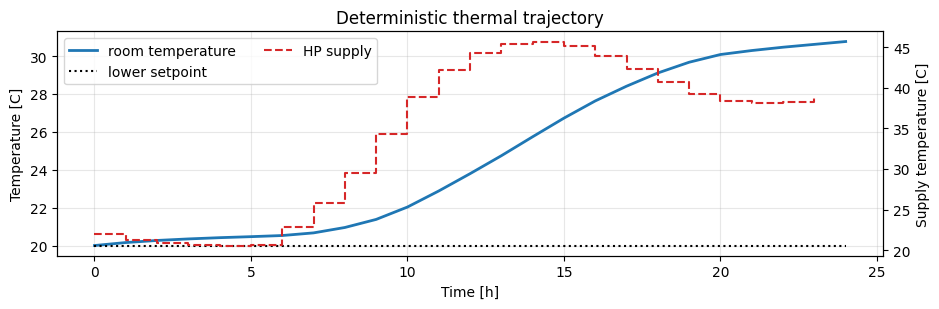

In [7]:

fig, ax_room = plt.subplots(figsize=(9.5, 3.2))
ax_supply = ax_room.twinx()

traj = main_case["traj"]
flow = main_case["flow"]

ax_room.plot(traj["time_h"], traj["T_room"], color="tab:blue", linewidth=2.0, label="room temperature")
ax_room.plot(traj["time_h"], traj["T_room_set_lower"], "k:", linewidth=1.5, label="lower setpoint")
ax_supply.step(flow["time_h"], flow["T_hp_sup"], where="post", color="tab:red", linestyle="--", linewidth=1.5, label="HP supply")

ax_room.set_title("Deterministic thermal trajectory")
ax_room.set_xlabel("Time [h]")
ax_room.set_ylabel("Temperature [C]")
ax_supply.set_ylabel("Supply temperature [C]")
ax_room.grid(True, alpha=0.3)

h1, l1 = ax_room.get_legend_handles_labels()
h2, l2 = ax_supply.get_legend_handles_labels()
ax_room.legend(h1 + h2, l1 + l2, loc="best", ncol=2)

plt.tight_layout()
plt.show()


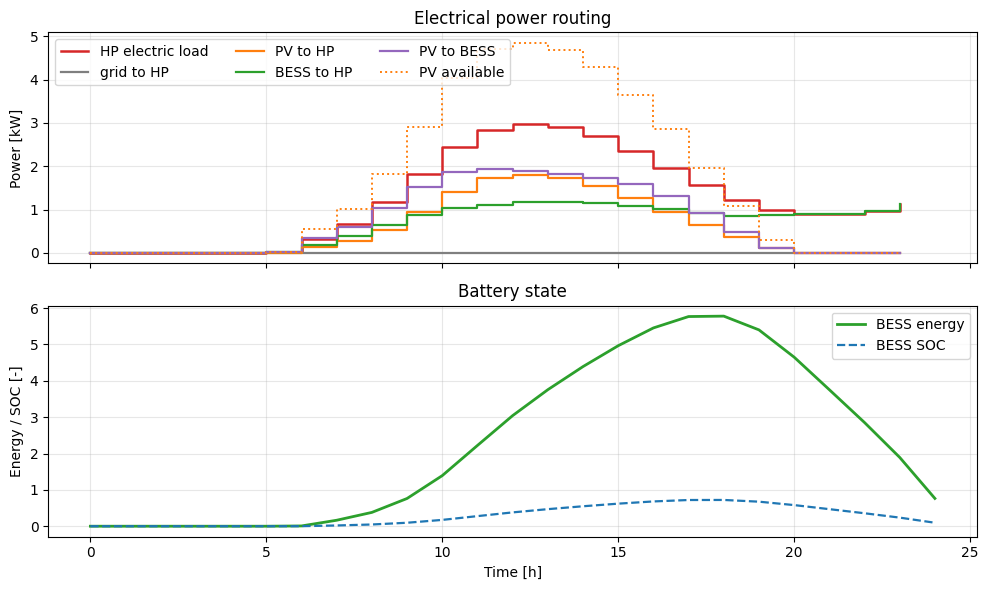

In [8]:

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
traj = main_case["traj"]
flow = main_case["flow"]

axes[0].step(flow["time_h"], flow["P_el_hp_kw"], where="post", color="tab:red", linewidth=1.8, label="HP electric load")
axes[0].step(flow["time_h"], flow["grid_to_hp_kw"], where="post", color="tab:gray", linewidth=1.6, label="grid to HP")
axes[0].step(flow["time_h"], flow["pv_to_hp_kw"], where="post", color="tab:orange", linewidth=1.6, label="PV to HP")
axes[0].step(flow["time_h"], flow["bess_to_hp_kw"], where="post", color="tab:green", linewidth=1.6, label="BESS to HP")
axes[0].step(flow["time_h"], flow["pv_to_bess_kw"], where="post", color="tab:purple", linewidth=1.6, label="PV to BESS")
axes[0].step(flow["time_h"], flow["pv_available_kw"], where="post", color="tab:orange", linestyle=":", linewidth=1.4, label="PV available")
axes[0].set_ylabel("Power [kW]")
axes[0].set_title("Electrical power routing")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best", ncol=3)

axes[1].plot(traj["time_h"], traj["E_bess_kwh"], color="tab:green", linewidth=2.0, label="BESS energy")
axes[1].plot(traj["time_h"], traj["bess_soc"], color="tab:blue", linewidth=1.6, linestyle="--", label="BESS SOC")
axes[1].set_xlabel("Time [h]")
axes[1].set_ylabel("Energy / SOC [-]")
axes[1].set_title("Battery state")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


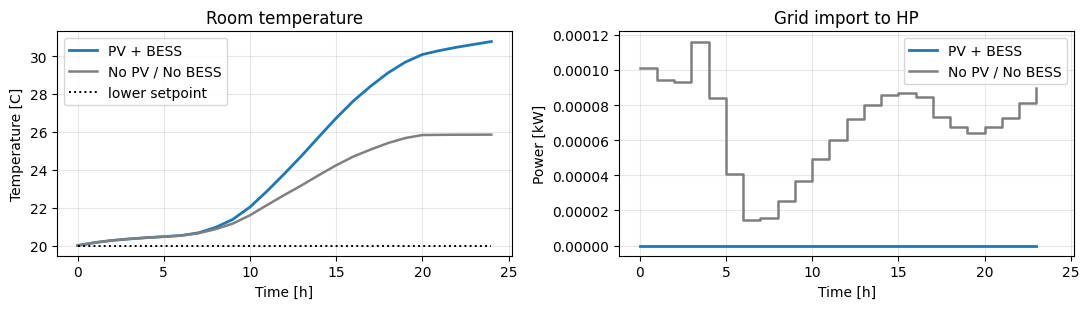

In [9]:

if solve_baseline_case:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True)

    axes[0].plot(main_case["traj"]["time_h"], main_case["traj"]["T_room"], color="tab:blue", linewidth=2.0, label="PV + BESS")
    axes[0].plot(baseline_case["traj"]["time_h"], baseline_case["traj"]["T_room"], color="tab:gray", linewidth=1.8, label="No PV / No BESS")
    axes[0].plot(main_case["traj"]["time_h"], main_case["traj"]["T_room_set_lower"], "k:", linewidth=1.4, label="lower setpoint")
    axes[0].set_title("Room temperature")
    axes[0].set_ylabel("Temperature [C]")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc="best")

    axes[1].step(main_case["flow"]["time_h"], main_case["flow"]["grid_to_hp_kw"], where="post", color="tab:blue", linewidth=2.0, label="PV + BESS")
    axes[1].step(baseline_case["flow"]["time_h"], baseline_case["flow"]["grid_to_hp_kw"], where="post", color="tab:gray", linewidth=1.8, label="No PV / No BESS")
    axes[1].set_title("Grid import to HP")
    axes[1].set_ylabel("Power [kW]")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="best")

    for ax in axes:
        ax.set_xlabel("Time [h]")

    plt.tight_layout()
    plt.show()
